In [13]:
import numpy as np
from folktables import ACSDataSource, ACSMobility, ACSEmployment
from matplotlib import pyplot as plt
import torch
from scipy import stats
from scipy.sparse.linalg import lobpcg
from scipy.linalg import eigh, eig
from sklearn.decomposition import PCA
import pandas as pd
from inFairness.distances import MahalanobisDistances, SquaredEuclideanDistance, LogisticRegSensitiveSubspace
from inFairness.fairalgo import SenSeI
from inFairness.auditor import SenSeIAuditor, SenSRAuditor
from tqdm.auto import tqdm
from utils import *

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import data

from ucimlrepo import fetch_ucirepo 

In [14]:
import importlib
import utils
importlib.reload(utils)
from utils import *

In [15]:
r = 3
p = 20
n = 120

In [16]:
results = pd.DataFrame(columns=[
        "Iterate",
        "AA^T to Kstar", 
        "Standard Train Loss", 
        "Fair Train Loss", 
        "Audit Mean", 
        "Audit Std", 
        "Audit Lower Bound",
        "True Audit Mean", 
        "True Audit Std", 
        "True Audit Lower Bound",
        "Worst Ratio", 
        "Worst Ratio True"
    ])

In [62]:
dataset = "gaussian.1"

if dataset.split(".")[0] == "gaussian":
    chi = float(dataset.split(".")[1])
    synthetic_covariance_diag = chi * np.ones(p)
    synthetic_covariance_indices = np.random.choice(range(p), size=int(p / 2), replace=False)
    synthetic_covariance_diag[synthetic_covariance_indices] = 1 / chi
    features = pd.DataFrame(np.random.multivariate_normal(np.zeros(p), np.diag(synthetic_covariance_diag), size=n * 2))

    signal = np.random.normal(0, 1, size=p)
    probs = 1 / (1 + np.exp(np.array(features) @ signal))
    labels = (np.random.uniform(size=2*n) < probs)
    labels = pd.DataFrame(labels).astype(int)

elif dataset.split(".")[0] == "binomial":
    chi = float(dataset.split(".")[1])
    probs = 1/chi * np.ones(p)
    probs_indices = np.random.choice(range(p), size=int(p / 2), replace=False)
    probs[probs_indices] = 1 - 1/chi
    features = pd.DataFrame(np.random.binomial(1, probs, size=(n * 2, p)))

    signal = np.random.normal(0, 1, size=p)
    probs = 1 / (1 + np.exp(np.array(features) @ signal))
    labels = (np.random.uniform(size=2*n) < probs)
    labels = pd.DataFrame(labels).astype(int)

elif dataset.split(".")[0] == "ar":
    chi = float(dataset.split(".")[1])
    rho = 1 - 1 / chi
    synthetic_covariance = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            synthetic_covariance[i, j] = rho ** np.abs(i - j)
    features = pd.DataFrame(np.random.multivariate_normal(np.zeros(p), synthetic_covariance, size=n * 2))

    signal = np.random.normal(0, 1, size=p)
    probs = 1 / (1 + np.exp(np.array(features) @ signal))
    labels = (np.random.uniform(size=2*n) < probs)
    labels = pd.DataFrame(labels).astype(int)
    
elif dataset == "ACSEmployment":
    data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
    acs_data = data_source.get_data(states=["TX"], download=True)
    features, labels, _ = ACSEmployment.df_to_pandas(acs_data)
    for column in ["MAR", "ESP", "MIG", "CIT", "MIL", "ANC", "RAC1P", "RELP"]:
        one_hot = pd.get_dummies(features[column])
        for c in one_hot.columns:
            one_hot = one_hot.rename(columns={c: f"{column}.{int(c)}"})
        features = features.join(one_hot)
        features = features.drop(column, axis=1)
    
elif dataset == "ACSMobility":
    data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
    acs_data = data_source.get_data(states=["TX"], download=True)
    features, labels, _ = ACSMobility.df_to_pandas(acs_data)
    for column in ["MAR", "ESP", "CIT", "MIL", "ANC", "RAC1P", "COW", "ESR", "RELP"]:
        one_hot = pd.get_dummies(features[column])
        for c in one_hot.columns:
            one_hot = one_hot.rename(columns={c: f"{column}.{int(c)}"})
        features = features.join(one_hot)
        features = features.drop(column, axis=1)

elif dataset == "CreditCardDefault":
    default_of_credit_card_clients = fetch_ucirepo(id=350) 
    features = default_of_credit_card_clients.data.features 
    labels = default_of_credit_card_clients.data.targets

    features["Married_Indicator"] = (features["X4"] == 1)
    features = features.drop("X4", axis=1)

elif dataset == "CommunityCrime":
    communities_and_crime = fetch_ucirepo(id=183) 
    X = communities_and_crime.data.features 
    features = X[np.setdiff1d(X.columns, ["state", "county", "community", "communityname", "fold"])]
    not_missing = ~(features == "?").any(axis=1)
    features = features[not_missing]
    features = features.sample(p, axis=1)
    labels = communities_and_crime.data.targets[not_missing]
    labels = (labels > labels.median())

elif dataset == "CDCDiabetes":
    cdc_diabetes_health_indicators = fetch_ucirepo(id=891)
    features = cdc_diabetes_health_indicators.data.features 
    labels = cdc_diabetes_health_indicators.data.targets 

X = clean_data(2 * n, p, features, cut_columns=False, pca=True)
X_train = X[:n]
X_test = X[n:]

Y = labels.head(2 * n)
Y_train = Y[:n]
Y_test = Y[n:]

p = X_train.shape[1]



In [63]:
labels.mean()

0    0.579167
dtype: float64

In [64]:
np.shape(X)

(240, 20)

In [65]:
M, S, y, Astar, Kstar = generate_synthetic_data(n, r, p, X_train)

In [66]:
with open('numpy_saves_{}.npz'.format(dataset), 'wb') as f:
    np.savez(f, 
             S=S, 
             y=y, 
             Astar=Astar, 
             Kstar=Kstar,
             X_train=X_train,
             X_test=X_test,
             Y_train=Y_train,
             Y_test=Y_test
            )

# with open('numpy_saves_{}.npz'.format(dataset), 'rb') as f:
#     loaded_data = np.load(f)
#     Astar = loaded_data["Astar"]
#     Kstar = loaded_data["Kstar"]
#     X_train = loaded_data["X_train"]
#     X_test = loaded_data["X_test"]
#     Y_train = loaded_data["Y_train"]
#     Y_test = loaded_data["Y_test"]

In [67]:
A0 = initialization(n, r, p, S, X_train, y) # np.random.normal(0, 1, size=(p, r)) / np.sqrt(n * p)
# A0 = A0 - np.mean(A0)

In [68]:
np.linalg.norm(A0 @ A0.T - Astar @ Astar.T)

0.4554952924695453

In [59]:
A_iterates = []
A = torch.tensor(A0, requires_grad=True, device="cpu").to(torch.float64)
dists = []


In [ ]:
y_tensor = torch.tensor(y, device="cpu")
M_tensor = torch.tensor(M, device="cpu")

for iterate in range(2500): # 20 * n):
    loss = L(A, y_tensor, M_tensor)
    loss.backward()
    with torch.no_grad():
        A -= A.grad * 0.1
        print(A.detach().cpu().numpy())
        A_iterates.append(np.array(A.detach().cpu().numpy()))
        dists.append(np.linalg.norm(A.detach().cpu().numpy() @ A.detach().cpu().numpy().T - Kstar))
        A.grad.zero_()
    with open('A_iterates_{}.npy'.format(dataset), 'wb') as f:
        np.save(f, np.array(A_iterates))
    print(iterate, dists[-1])
    

[[ 2.19158751e-02 -1.02566716e-01  5.54430985e-02]
 [-2.21318749e-02 -7.14252320e-02  9.15342424e-02]
 [ 1.59961687e-02 -3.18971138e-02  3.03258132e-02]
 [ 5.46762388e-02  3.73378817e-02  2.19177854e-01]
 [ 2.15787257e-02  1.41261144e-01 -4.00001836e-02]
 [ 1.36619379e-03 -9.52986694e-02  5.47751108e-02]
 [-3.44353708e-02 -3.72707113e-02 -4.79079797e-02]
 [ 4.67042064e-02 -3.75755909e-02 -3.02612669e-02]
 [-7.26930342e-02  7.80215203e-02  1.03634346e-01]
 [ 1.42740186e-02  1.59990769e-02 -6.71010765e-02]
 [-5.21582544e-04 -3.51897189e-02  3.35236812e-02]
 [ 2.05526633e-02  2.03230794e-03 -4.30741448e-02]
 [ 1.51061578e-02  9.40834505e-02 -1.98674000e-02]
 [-4.47450436e-02  9.76638512e-03  5.98265823e-02]
 [ 8.40241570e-05 -9.14958953e-02  5.04184026e-02]
 [ 7.53168289e-03  6.44868570e-02  6.67177301e-02]
 [-2.37004221e-03 -3.46496767e-02 -1.58098759e-01]
 [ 8.94932233e-03  1.33669623e-01  1.05681562e-01]
 [-1.35121394e-02  6.40221703e-02 -1.17176027e-01]
 [-2.10655930e-02  2.54402149e-


KeyboardInterrupt



In [61]:
A_iterates

[array([[ 2.19158751e-02, -1.02566716e-01,  5.54430985e-02],
        [-2.21318749e-02, -7.14252320e-02,  9.15342424e-02],
        [ 1.59961687e-02, -3.18971138e-02,  3.03258132e-02],
        [ 5.46762388e-02,  3.73378817e-02,  2.19177854e-01],
        [ 2.15787257e-02,  1.41261144e-01, -4.00001836e-02],
        [ 1.36619379e-03, -9.52986694e-02,  5.47751108e-02],
        [-3.44353708e-02, -3.72707113e-02, -4.79079797e-02],
        [ 4.67042064e-02, -3.75755909e-02, -3.02612669e-02],
        [-7.26930342e-02,  7.80215203e-02,  1.03634346e-01],
        [ 1.42740186e-02,  1.59990769e-02, -6.71010765e-02],
        [-5.21582544e-04, -3.51897189e-02,  3.35236812e-02],
        [ 2.05526633e-02,  2.03230794e-03, -4.30741448e-02],
        [ 1.51061578e-02,  9.40834505e-02, -1.98674000e-02],
        [-4.47450436e-02,  9.76638512e-03,  5.98265823e-02],
        [ 8.40241570e-05, -9.14958953e-02,  5.04184026e-02],
        [ 7.53168289e-03,  6.44868570e-02,  6.67177301e-02],
        [-2.37004221e-03

In [130]:
pd.DataFrame(dists).to_csv(f"dists_{dataset}.csv")

In [10]:
import re

A_iterates_loaded = []
with open(f"A_iterates_{dataset}.txt", "r") as f:
    text = f.read()
    text = text + "\n"
    text = re.sub('[0-9]+ 0.[0-9]+\n','',text)
    text = text.strip("\n")
    for matrix in text.split("]]\n[["):
        m = []
        for line in matrix.split("\n"):
            line = line.strip("[] ")
            line = re.sub("[ ]+", ",", line)
            m.append([float(x) for x in line.split(",")])
        A = np.array(m)
        A_iterates_loaded.append(A)

In [11]:
dists_check = []
for A in A_iterates_loaded:
    dists_check.append(np.linalg.norm(A @ A.T - Kstar))

    

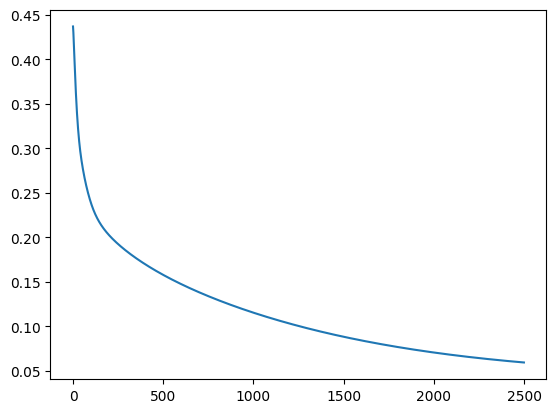

In [13]:
plt.plot(dists_check)

In [44]:
X_train_t = torch.Tensor(np.array(X_train))
Y_train_t = torch.Tensor(np.array(Y_train))

X_test_t = torch.Tensor(np.array(X_test))
Y_test_t = torch.Tensor(np.array(Y_test))

train_dataset = TrainDataset(X_train_t, Y_train_t)
test_dataset = TrainDataset(X_test_t, Y_test_t)

train_dl = torch.utils.data.DataLoader(train_dataset, batch_size=8)
test_dl = torch.utils.data.DataLoader(test_dataset, batch_size=8)

network_standard = NeuralNet(p)
optimizer = torch.optim.Adam(network_standard.parameters(), lr=1e-3)
loss_fn = torch.nn.functional.binary_cross_entropy

network_standard.train()

for epoch in range(2000):

    for x, y in train_dl:
        optimizer.zero_grad()
        y_pred = network_standard(x)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
    # print(loss)

standard_loss = loss

In [45]:
y_pred

tensor([[1.6290e-07],
        [1.0407e-07],
        [6.7803e-09],
        [1.0000e+00],
        [1.0000e+00],
        [1.0000e+00],
        [1.0000e+00],
        [1.0000e+00]], grad_fn=<SigmoidBackward0>)

In [15]:
total = 0
total_correct = 0
for x, y in test_dl:
    y_pred = network_standard(x)
    y_pred_bin = (y_pred > 0.5).to(int)
    num_correct = torch.sum((y_pred_bin == y).to(int))
    total_correct += num_correct
    total += len(y)
total_correct / total

tensor(0.7500)

In [16]:
np.mean(Y_test)

0.23333333333333334

In [17]:
standard_loss

tensor(1.0405e-06, grad_fn=<BinaryCrossEntropyBackward0>)

In [18]:
input_metric_true = MahalanobisDistances()
input_metric_true.fit(torch.Tensor(Astar @ Astar.T))

output_metric = SquaredEuclideanDistance()
output_metric.fit(num_dims=1)

rho = 5
eps = 0.1
auditor_nsteps = 100
auditor_lr = 0.001

In [20]:
for A in [A_iterates_loaded[i] for i in [0, 1000, 2000, -1]]:
    print(i)
    network = NeuralNet(p)
    
    input_metric = MahalanobisDistances()
    input_metric.fit(torch.Tensor(A @ A.T))

    alg = SenSeI(network, input_metric, output_metric, loss_fn, rho, eps, auditor_nsteps, auditor_lr)

    optimizer = torch.optim.Adam(network.parameters(), lr=0.001)

    alg.train()

    for epoch in range(2000):
        for x, y in train_dl:
            optimizer.zero_grad()
            result = alg(x, torch.reshape(y, (-1, 1)))
            result.loss.backward()
            optimizer.step()
        print(result.loss)
        if result.loss < standard_loss:
            print("Stopping")
            break

    fair_loss = result.loss

    auditor = SenSeIAuditor(input_metric, output_metric, auditor_nsteps, auditor_lr)
    auditor_true = SenSeIAuditor(input_metric_true, output_metric, auditor_nsteps, auditor_lr)

    audit = auditor.audit(network, X_test_t, Y_test_t, torch.nn.functional.l1_loss)
    audit_true = auditor_true.audit(network, X_test_t, Y_test_t, torch.nn.functional.l1_loss)

    ratios = []
    for X_1 in X_test_t:
        for X_2 in X_test_t:
            ratios.append((output_metric(network(X_1), network(X_2)) / input_metric(X_1, X_2)).detach().numpy())
    ratios = np.array(ratios)
    worst_ratio = np.max(ratios[~np.isnan(ratios)])
    mean_ratio = np.mean(ratios[~np.isnan(ratios)])
    std_ratio = np.std(ratios[~np.isnan(ratios)])

    ratios = []
    for X_1 in X_test_t:
        for X_2 in X_test_t:
            ratios.append((output_metric(network(X_1), network(X_2)) / input_metric_true(X_1, X_2)).detach().numpy())
    ratios = np.array(ratios)
    worst_ratio_true = np.max(ratios[~np.isnan(ratios)])
    mean_ratio_true = np.mean(ratios[~np.isnan(ratios)])
    std_ratio_true = np.std(ratios[~np.isnan(ratios)])

    print(fair_loss.detach().numpy(), audit, audit_true, worst_ratio, worst_ratio_true, 
          mean_ratio, mean_ratio_true, std_ratio, std_ratio_true)

tensor(0.6111, grad_fn=<MeanBackward0>)
tensor(0.5847, grad_fn=<MeanBackward0>)
tensor(0.5714, grad_fn=<MeanBackward0>)
tensor(0.5643, grad_fn=<MeanBackward0>)
tensor(0.5594, grad_fn=<MeanBackward0>)
tensor(0.5553, grad_fn=<MeanBackward0>)
tensor(0.5512, grad_fn=<MeanBackward0>)
tensor(0.5472, grad_fn=<MeanBackward0>)
tensor(0.5431, grad_fn=<MeanBackward0>)
tensor(0.5389, grad_fn=<MeanBackward0>)
tensor(0.5347, grad_fn=<MeanBackward0>)
tensor(0.5304, grad_fn=<MeanBackward0>)
tensor(0.5262, grad_fn=<MeanBackward0>)
tensor(0.5218, grad_fn=<MeanBackward0>)
tensor(0.5176, grad_fn=<MeanBackward0>)
tensor(0.5133, grad_fn=<MeanBackward0>)
tensor(0.5091, grad_fn=<MeanBackward0>)
tensor(0.5052, grad_fn=<MeanBackward0>)
tensor(0.5012, grad_fn=<MeanBackward0>)
tensor(0.4974, grad_fn=<MeanBackward0>)
tensor(0.4937, grad_fn=<MeanBackward0>)
tensor(0.4906, grad_fn=<MeanBackward0>)
tensor(0.4882, grad_fn=<MeanBackward0>)
tensor(0.4848, grad_fn=<MeanBackward0>)
tensor(0.4810, grad_fn=<MeanBackward0>)


In [5]:
Y_train.mean()

0    0.546808
dtype: float32